In [1]:
import torch

FP4_GRID = torch.tensor([
    -6.0,
    -4.0,
    -3.0,
    -2.0,
    -1.5,
    -1.0,
    -0.5,
    -0.0,
    +0.0,
    +0.5,
    +1.0,
    +1.5,
    +2.0,
    +3.0,
    +4.0,
    +6.0,
])

def round_scales(scales):            
    s_dec = scales.max() / (447.99 * 6.0)
    s_dec[s_dec == 0] = 1.0
    s_dec_b = scales / 6.0
    s_dec_b_e4m3 = (s_dec_b / s_dec).to(torch.float8_e4m3fn).float()
    s_dec_b_e4m3[s_dec_b_e4m3 == 0] = 1.0
    s_enc_b_inv = s_dec_b_e4m3 * s_dec
    return s_enc_b_inv


def get_gaussian() -> torch.Tensor:
    return torch.randn((2**20, 16))
    
    
def normalize(x: torch.Tensor) -> (torch.Tensor, torch.Tensor):
    scales = x.abs().max(dim=-1, keepdim=True)[0]
    rounded_scales = round_scales(scales)

    return x / rounded_scales, rounded_scales

def index_rtn_grid(x: torch.Tensor, grid: torch.Tensor) -> torch.Tensor:
    inds = torch.bucketize(x, grid)

    lo = torch.clamp(inds - 1, min=0, max=grid.shape[-1] - 1)
    hi = torch.clamp(inds,     min=0, max=grid.shape[-1] - 1)

    low = grid[lo]
    high = grid[hi]

    return torch.where(
        (high - x) <= (x - low),
        hi,
        lo,
    )


def rtn_grid(x: torch.Tensor, grid: torch.Tensor) -> torch.Tensor:
    rtn_inds = index_rtn_grid(x, grid)
    return grid[rtn_inds]

In [2]:
x = get_gaussian()
x_norm, scales = normalize(x)

In [3]:
def quantize_nvfp4(x_norm: torch.Tensor, scales: torch.Tensor) -> torch.Tensor:
    return rtn_grid(x_norm, FP4_GRID) * scales

x_fp4 = quantize_nvfp4(x_norm, scales)
err_fp4 = (x - x_fp4).pow(2).mean() / x.pow(2).mean()
print(f"NVFP4 err: {err_fp4:.4f}")

NVFP4 err: 0.0091


In [4]:
def get_best_fp4_downcast(x_norm: torch.Tensor) -> torch.Tensor:
    rtn_inds = index_rtn_grid(x_norm, FP4_GRID)
    
    downcast = rtn_inds >> 1 
    x_flat = x_norm.flatten()
    downcast_flat = downcast.flatten()
    group_sums = torch.bincount(downcast_flat, weights=x_flat)
    group_counts = torch.bincount(downcast_flat)
    centers_of_mass = group_sums / group_counts.clamp(min=1)
    
    return centers_of_mass

In [5]:
BEST_FP4_DOWNCAST = get_best_fp4_downcast(x_norm)
BEST_FP4_DOWNCAST

tensor([-4.8912, -2.5503, -1.2363, -0.3729,  0.3725,  1.2357,  2.5500,  4.8895])

In [6]:
def quantize_best_fp4_downcast(x_norm: torch.Tensor, scales: torch.Tensor) -> torch.Tensor:
    rtn_inds = index_rtn_grid(x_norm, FP4_GRID)
    downcast = rtn_inds >> 1
    
    decoded = BEST_FP4_DOWNCAST[downcast]
    
    return decoded * scales

x_fp4_downcast = quantize_best_fp4_downcast(x_norm, scales)
err_fp4_downcast = (x - x_fp4_downcast).pow(2).mean() / x.pow(2).mean()
print(f"NVFP4 err: {err_fp4:.4f}")
print(f"NVFP4->LUT3 Downcast err: {err_fp4_downcast:.4f}")

NVFP4 err: 0.0091
NVFP4->LUT3 Downcast err: 0.0364


In [7]:
print(f"NVFP4 err: {err_fp4:.4f}")
print(f"NVFP4->LUT3 Downcast err: {err_fp4_downcast:.4f}")

NVFP4 err: 0.0091
NVFP4->LUT3 Downcast err: 0.0364


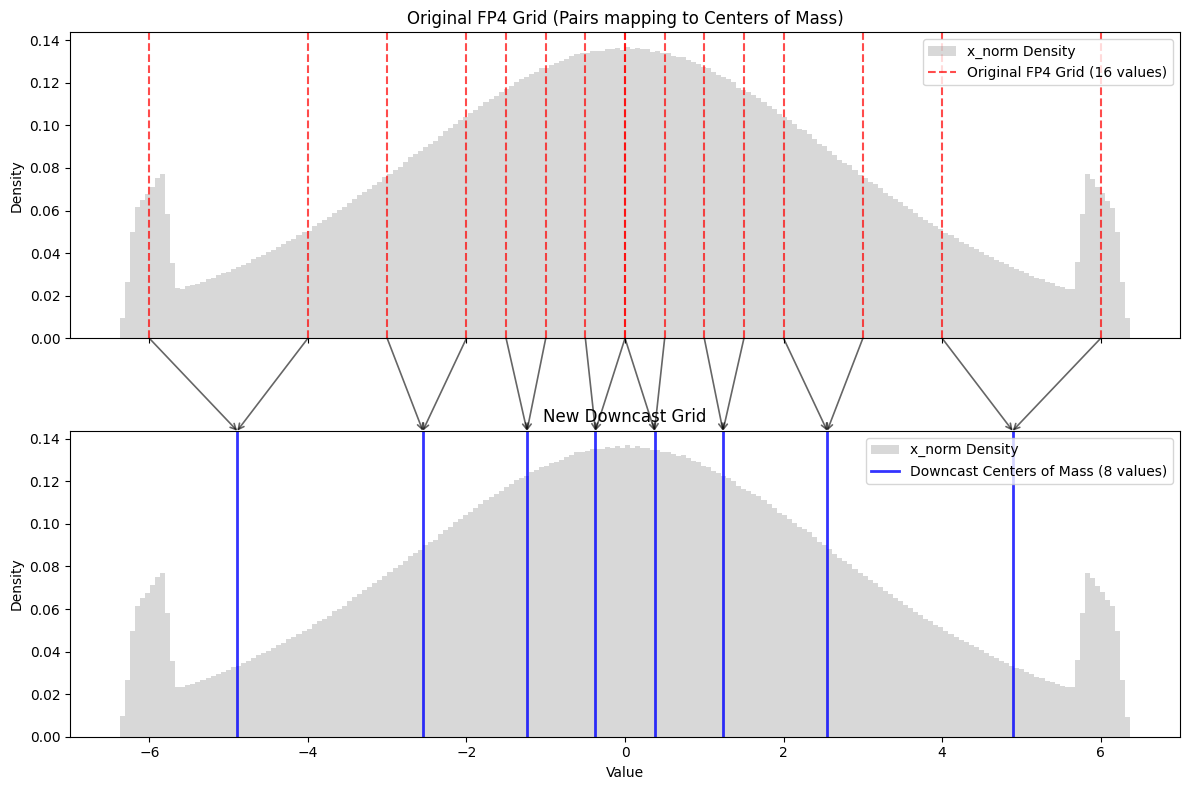

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch


# 3. Plotting Setup
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
x_np = x_norm.flatten().numpy()

# Plot x_norm density on both subplots
ax1.hist(x_np, bins=200, density=True, alpha=0.3, color='gray', label='x_norm Density')
ax2.hist(x_np, bins=200, density=True, alpha=0.3, color='gray', label='x_norm Density')

max_y2 = ax2.get_ylim()[1]

# 4. Plot Original Grid (Top)
for i, val in enumerate(FP4_GRID):
    label = 'Original FP4 Grid (16 values)' if i == 0 else ""
    ax1.axvline(val.item(), color='red', linestyle='--', alpha=0.7, label=label)

# 5. Plot Downcast Centers of Mass (Bottom)
for i, val in enumerate(BEST_FP4_DOWNCAST):
    label = 'Downcast Centers of Mass (8 values)' if i == 0 else ""
    ax2.axvline(val.item(), color='blue', linestyle='-', linewidth=2, alpha=0.8, label=label)

# 6. Draw Connection Arrows
for i, val in enumerate(FP4_GRID):
    com_idx = i >> 1
    com_val = BEST_FP4_DOWNCAST[com_idx].item()
    
    # ConnectionPatch maps coordinates across different subplots
    con = ConnectionPatch(
        xyA=(val.item(), 0),          # Start at y=0 on ax1 (bottom of top subplot)
        xyB=(com_val, max_y2),        # End at max_y on ax2 (top of bottom subplot)
        coordsA="data", coordsB="data", 
        axesA=ax1, axesB=ax2, 
        color="black", arrowstyle="->", shrinkB=0, lw=1.2, alpha=0.6
    )
    ax1.add_artist(con)

# Formatting
ax1.set_title("Original FP4 Grid (Pairs mapping to Centers of Mass)")
ax2.set_title("New Downcast Grid")
ax1.set_ylabel("Density")
ax2.set_ylabel("Density")
ax2.set_xlabel("Value")
ax1.set_xlim(-7, 7)

ax1.legend(loc='upper right')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('fp4_downcast_visualization.png', dpi=150)

## Standalone implementation

In [9]:
import torch


FP4_GRID = torch.tensor([
    -6.0,
    -4.0,
    -3.0,
    -2.0,
    -1.5,
    -1.0,
    -0.5,
    -0.0,
    +0.0,
    +0.5,
    +1.0,
    +1.5,
    +2.0,
    +3.0,
    +4.0,
    +6.0,
])


BEST_FP4_DOWNCAST_GRID = torch.tensor([
    -4.890,
    -2.550,
    -1.236,
    -0.372,
    +0.372,
    +1.236,
    +2.550,
    +4.890,
])


def round_scales(scales):            
    s_dec = scales.max() / (447.99 * 6.0)
    s_dec[s_dec == 0] = 1.0
    s_dec_b = scales / 6.0
    s_dec_b_e4m3 = (s_dec_b / s_dec).to(torch.float8_e4m3fn).float()
    s_dec_b_e4m3[s_dec_b_e4m3 == 0] = 1.0
    s_enc_b_inv = s_dec_b_e4m3 * s_dec
    return s_enc_b_inv


def index_rtn_grid(x: torch.Tensor, grid: torch.Tensor) -> torch.Tensor:
    inds = torch.bucketize(x, grid)

    lo = torch.clamp(inds - 1, min=0, max=grid.shape[-1] - 1)
    hi = torch.clamp(inds,     min=0, max=grid.shape[-1] - 1)

    low = grid[lo]
    high = grid[hi]

    return torch.where(
        (high - x) <= (x - low),
        hi,
        lo,
    )

def downcast_double_round(x: torch.Tensor) -> (torch.Tensor, torch.Tensor):
    assert x.device == FP4_GRID.device
    assert x.device == BEST_FP4_DOWNCAST_GRID.device
    assert x.numel() % 16 == 0
    
    orig_shape = x.shape
    x_g = x.reshape(-1, 16)
    scales = x_g.abs().max(dim=-1, keepdim=True)[0]
    rounded_scales = round_scales(scales)
    
    x_scaled = x_g / scales
    
    fp4_idx = index_rtn_grid(x_scaled, FP4_GRID)
    downcast_idx = fp4_idx >> 1
    
    x_fp4 = FP4_GRID[fp4_idx] * scales
    x_dc3 = BEST_FP4_DOWNCAST_GRID[downcast_idx] * scales
    
    return x_fp4.reshape(orig_shape), x_dc3.reshape(orig_shape)
    

In [10]:
x = torch.randn(2**20)
x_fp4, x_dc3 = downcast_double_round(x)

fp4_err = (x - x_fp4).pow(2).mean() / x.pow(2).mean()
dc3_err = (x - x_dc3).pow(2).mean() / x.pow(2).mean()

print(f"FP4 err: {fp4_err:.3f}")
print(f"DC3 err: {dc3_err:.3f}")

FP4 err: 0.089
DC3 err: 0.242
